## Ejercicio Time Series Forecast
Vamos a predecir la demanda de pasajeros de una aerolínea usando el dataset AirPassengers. Voy a combinar explicación conceptual y código en cada apartado.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error

/opt/homebrew/Caskroom/miniforge/base/envs/dl/lib/python3.11/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.stats import gaussian_kde


## 1. Carga datos y representa la serie
Cargamos el CSV y configuramos el índice temporal. Luego pintamos la serie para detectar visualmente tendencia y estacionalidad. La **estacionalidad** es un patrón que se repite con una frecuencia constante (semanal, mensual, anual...). En este dataset esperamos ciclos anuales: los meses de verano concentran más viajes.

Primeras filas:
            value
date             
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121

Rango: January 1949 → December 1960
Total: 144 observaciones mensuales


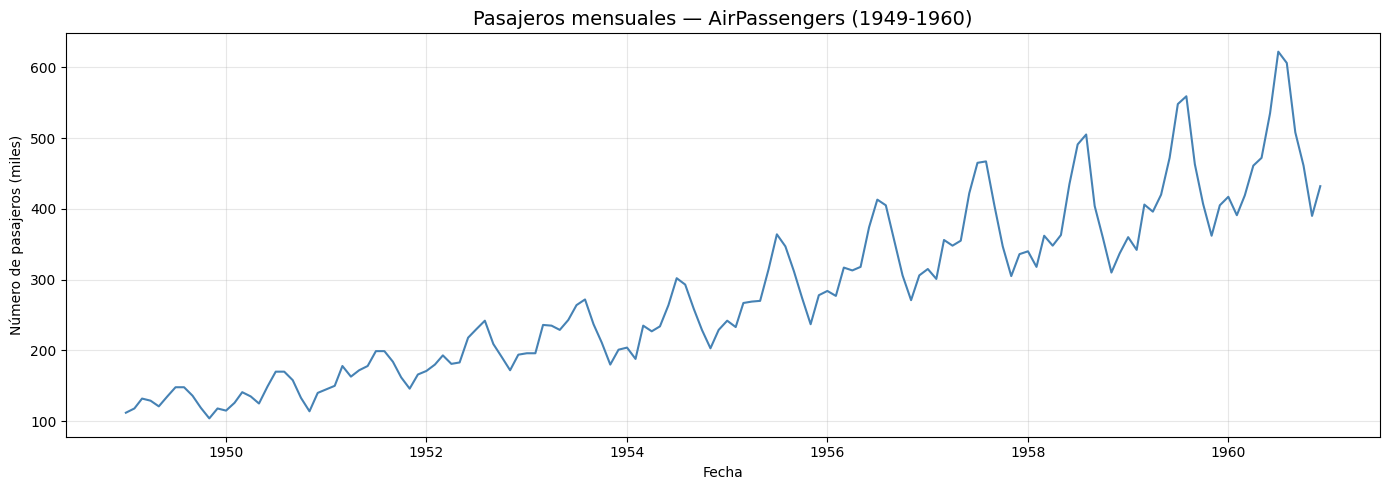


Observaciones visuales:
- Tendencia: sí, claramente ascendente
- Estacionalidad: sí, picos cada verano → ciclo anual
- Varianza: creciente (los picos se hacen más grandes con el tiempo)
→ seasonality = 12 (meses)


In [2]:
# Cargamos el CSV. La columna de fecha se llama 'date' y los pasajeros 'value'
df = pd.read_csv('/Users/andoni/2026-02-BILBAO-FT-Data-Science/3-Machine_Learning/4-Series temporales/ejercicios/data/AirPassengers.csv')

# Parseamos la fecha y la convertimos en índice
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

print('Primeras filas:')
print(df.head())
print(f'\nRango: {df.index.min().strftime("%B %Y")} → {df.index.max().strftime("%B %Y")}')
print(f'Total: {len(df)} observaciones mensuales')

# Visualizamos la serie completa
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['value'], color='steelblue', linewidth=1.5)
ax.set_title('Pasajeros mensuales — AirPassengers (1949-1960)', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('Número de pasajeros (miles)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nObservaciones visuales:')
print('- Tendencia: sí, claramente ascendente')
print('- Estacionalidad: sí, picos cada verano → ciclo anual')
print('- Varianza: creciente (los picos se hacen más grandes con el tiempo)')
print('→ seasonality = 12 (meses)')

## 2. Serie original + rolling window con el valor de seasonality
Superponemos la serie original con su media móvil de ventana = 12 (el periodo estacional). Esto suaviza los ciclos estacionales y deja ver sólo la tendencia subyacente.

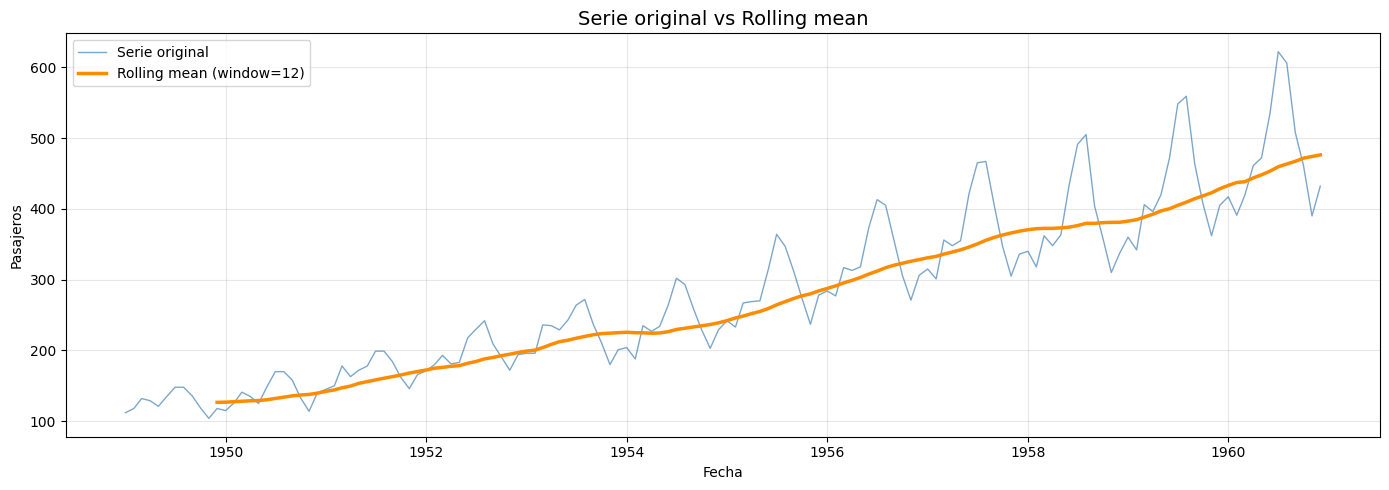

In [3]:
# Usamos window=12 porque el seasonality detectado es 12 meses
seasonality = 12
rolling_mean = df['value'].rolling(window=seasonality).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['value'],
        color='steelblue', linewidth=1, alpha=0.7, label='Serie original')
ax.plot(df.index, rolling_mean,
        color='darkorange', linewidth=2.5, label=f'Rolling mean (window={seasonality})')
ax.set_title('Serie original vs Rolling mean', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('Pasajeros')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. ¿Es la serie estacionaria?
Usamos el **test ADF (Augmented Dickey-Fuller)**. La hipótesis nula (H₀) es que la serie NO es estacionaria. Si el p-valor es mayor que 0.05, no podemos rechazarla → confirmamos no estacionariedad.

In [4]:
from statsmodels.tsa.stattools import adfuller

# Aplicamos el test ADF sobre la serie original
adf_result = adfuller(df['value'])
print('=== Test ADF ===')
print(f'  Estadístico ADF: {adf_result[0]:.4f}')
print(f'  p-valor:         {adf_result[1]:.4f}')
if adf_result[1] > 0.05:
    print('  → p > 0.05: NO rechazamos H0 → la serie NO es estacionaria ✓')
    print('  Conclusión: necesitaremos transformarla antes de modelar')

=== Test ADF ===
  Estadístico ADF: 0.8154
  p-valor:         0.9919
  → p > 0.05: NO rechazamos H0 → la serie NO es estacionaria ✓
  Conclusión: necesitaremos transformarla antes de modelar


## 4. Transformación logarítmica
El problema de AirPassengers es que la **varianza crece con el tiempo**: los picos de verano de 1960 son mucho más grandes que los de 1950. Esto viola uno de los requisitos de estacionariedad.

La solución es aplicar `np.log()`: el logaritmo comprime los valores grandes proporcionalmente, estabilizando la varianza. Los ciclos estacionales pasan de crecer a tener amplitud aproximadamente constante.

Importante: al final del forecast tendremos que invertir con `np.exp()` para volver a pasajeros reales.

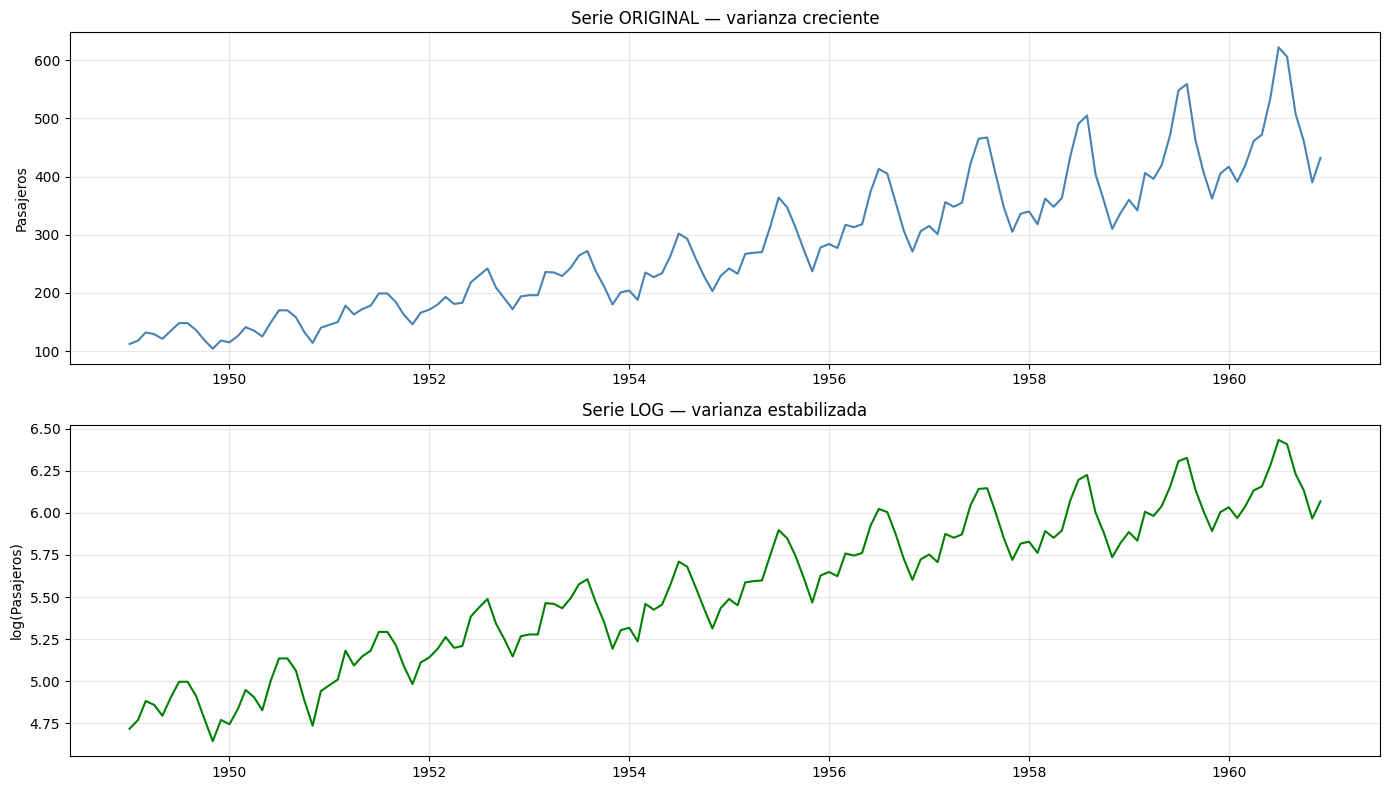

Observación: en la serie log los picos de verano tienen altura similar en 1950 y 1960.
La varianza ya no crece con el nivel → la transformación funciona.


In [5]:
# Aplicamos la transformación logarítmica
df['log_value'] = np.log(df['value'])

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df.index, df['value'], color='steelblue', linewidth=1.5)
axes[0].set_title('Serie ORIGINAL — varianza creciente', fontsize=12)
axes[0].set_ylabel('Pasajeros')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df.index, df['log_value'], color='green', linewidth=1.5)
axes[1].set_title('Serie LOG — varianza estabilizada', fontsize=12)
axes[1].set_ylabel('log(Pasajeros)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Observación: en la serie log los picos de verano tienen altura similar en 1950 y 1960.')
print('La varianza ya no crece con el nivel → la transformación funciona.')

## 5. Divide en train y test (20 muestras para test)
En series temporales el split es **siempre cronológico**: nunca aleatorio. Si mezcláamos datos del futuro en el entrenamiento, el modelo 'vería el futuro' durante el entrenamiento y los resultados serían artificialmente buenos (data leakage).

Guardamos las últimas 20 observaciones para test y el resto para train. Trabajamos sobre la serie transformada (`log_value`).

Train: 124 observaciones (Jan 1949 → Apr 1959)
Test:  20 observaciones  (May 1959 → Dec 1960)


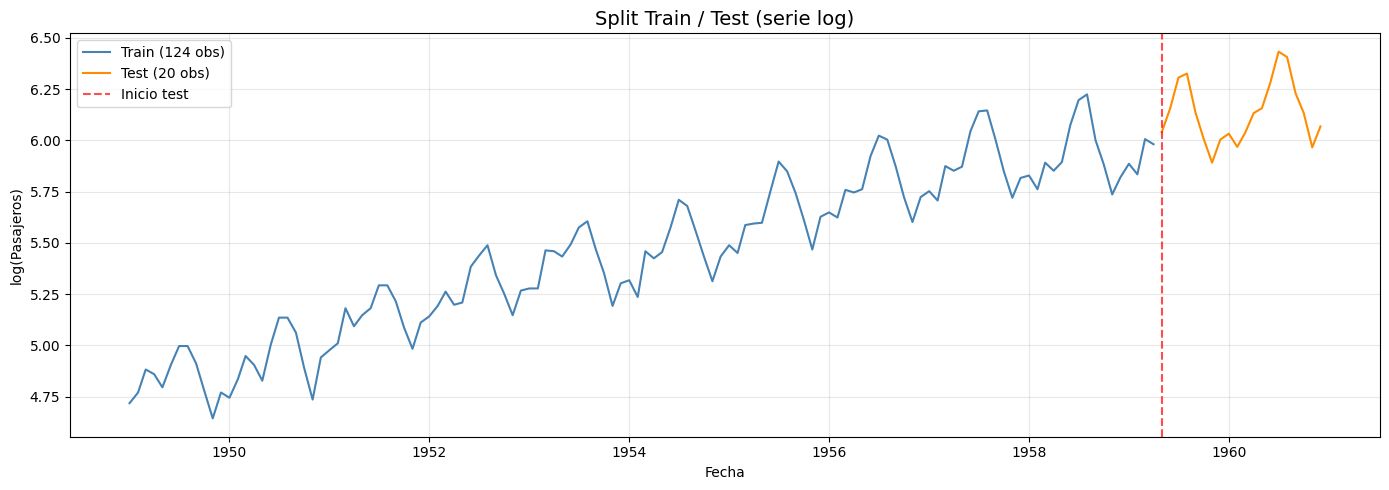

In [6]:
# Guardamos las últimas 20 observaciones para test
# El split es cronológico: train = todo menos las últimas 20, test = las últimas 20
train = df['log_value'].iloc[:-20]
test  = df['log_value'].iloc[-20:]

print(f'Train: {len(train)} observaciones ({train.index[0].strftime("%b %Y")} → {train.index[-1].strftime("%b %Y")})')
print(f'Test:  {len(test)} observaciones  ({test.index[0].strftime("%b %Y")} → {test.index[-1].strftime("%b %Y")})')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, train.values, color='steelblue', linewidth=1.5, label=f'Train ({len(train)} obs)')
ax.plot(test.index,  test.values,  color='darkorange', linewidth=1.5, label=f'Test ({len(test)} obs)')
ax.axvline(x=test.index[0], color='red', linestyle='--', alpha=0.7, label='Inicio test')
ax.set_title('Split Train / Test (serie log)', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('log(Pasajeros)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Modelo ARIMA
Usamos `auto_arima` de la librería `pmdarima`, que prueba automáticamente distintas combinaciones de parámetros y selecciona la que minimiza el **AIC** (Akaike Information Criterion — penaliza la complejidad para evitar sobreajuste).

Los parámetros clave de SARIMA son:
- `p, d, q` — parte no estacional (AR, diferenciación, MA)
- `P, D, Q` — parte estacional (mismos conceptos pero a escala del periodo)
- `m=12` — el periodo estacional que detectamos (12 meses = 1 año)

Medimos el error con **MAE** y **RMSE**. Ojo: las predicciones salen en escala logarítmica, así que invertimos con `np.exp()` para comparar en pasajeros reales.

In [7]:
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error

# auto_arima busca la mejor combinación de hiperparámetros
# seasonal=True activa la búsqueda de parámetros estacionales
# m=12 indica que el ciclo es anual (12 meses)
# stepwise=True hace la búsqueda más rápida (no prueba todas las combinaciones)
print('Buscando el mejor modelo ARIMA... (puede tardar unos segundos)')
modelo = auto_arima(
    train,
    seasonal=True,
    m=12,
    stepwise=True,
    information_criterion='aic',
    suppress_warnings=True,
    error_action='ignore'
)
print(modelo.summary())

# Predecimos sobre el periodo de test (n_periods = número de pasos a predecir)
pred_log = modelo.predict(n_periods=len(test))

# Invertimos la transformación logarítmica para comparar en pasajeros reales
pred_real = np.exp(pred_log)
test_real  = np.exp(test.values)

# Calculamos las métricas de error
mae  = mean_absolute_error(test_real, pred_real)
rmse = np.sqrt(mean_squared_error(test_real, pred_real))

print(f'\n=== Métricas SARIMA (en escala original de pasajeros) ===')
print(f'  MAE:  {mae:.1f} pasajeros')
print(f'  RMSE: {rmse:.1f} pasajeros')

Buscando el mejor modelo ARIMA... (puede tardar unos segundos)
                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  124
Model:             SARIMAX(2, 0, 0)x(0, 1, [1], 12)   Log Likelihood                 211.190
Date:                              Sun, 10 May 2026   AIC                           -412.379
Time:                                      19:06:56   BIC                           -398.787
Sample:                                  01-01-1949   HQIC                          -406.864
                                       - 04-01-1959                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0190      0.010   

## 7. Representar los datos de test y las predicciones
Pintamos el histórico completo, los valores reales del periodo test y las predicciones del modelo, todo en escala original (pasajeros reales, no en log).

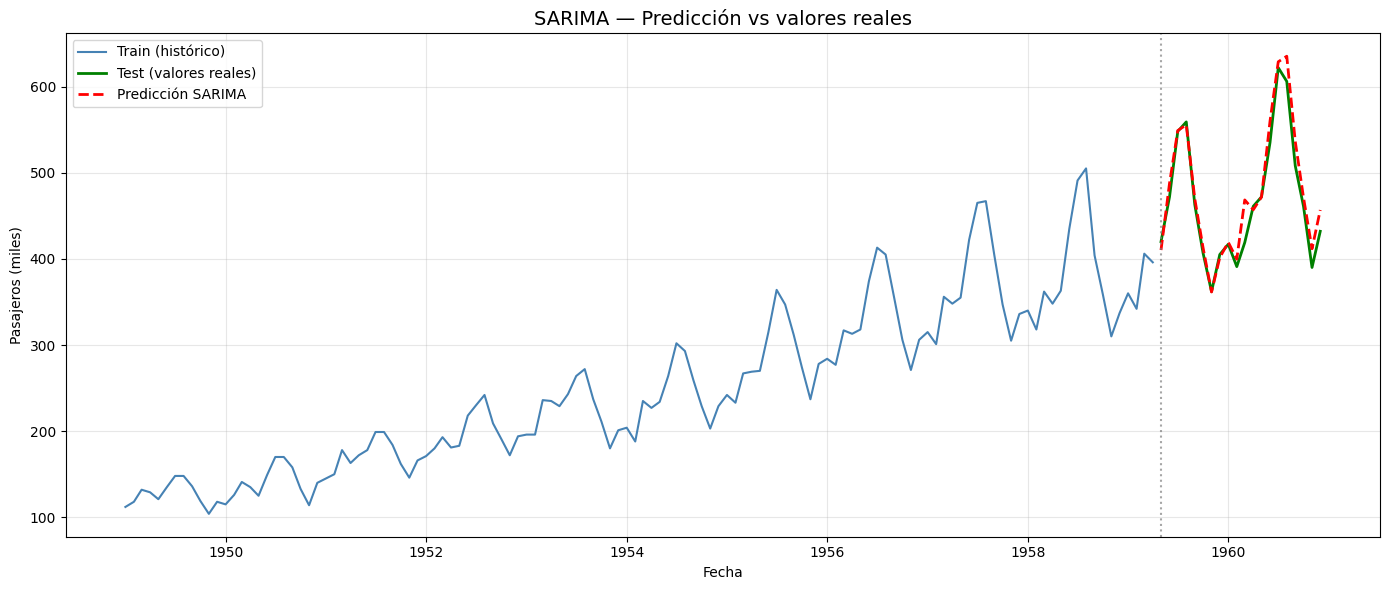

             Real  Predicción  Error abs
date                                    
1959-05-01  420.0       410.0       10.0
1959-06-01  472.0       488.0       16.0
1959-07-01  548.0       549.0        1.0
1959-08-01  559.0       556.0        3.0
1959-09-01  463.0       470.0        7.0
1959-10-01  407.0       413.0        6.0
1959-11-01  362.0       362.0        0.0
1959-12-01  405.0       401.0        4.0
1960-01-01  417.0       419.0        2.0
1960-02-01  391.0       400.0        9.0
1960-03-01  419.0       468.0       49.0
1960-04-01  461.0       457.0        4.0
1960-05-01  472.0       472.0        0.0
1960-06-01  535.0       560.0       25.0
1960-07-01  622.0       629.0        7.0
1960-08-01  606.0       635.0       29.0
1960-09-01  508.0       536.0       28.0
1960-10-01  461.0       471.0       10.0
1960-11-01  390.0       412.0       22.0
1960-12-01  432.0       457.0       25.0


In [8]:
# Pasamos todo a escala original para la visualización
train_real_plot = np.exp(train)
test_real_plot  = np.exp(test)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train_real_plot.index, train_real_plot.values,
        color='steelblue', linewidth=1.5, label='Train (histórico)')
ax.plot(test_real_plot.index, test_real_plot.values,
        color='green', linewidth=2, label='Test (valores reales)')
ax.plot(test_real_plot.index, pred_real,
        color='red', linewidth=2, linestyle='--', label='Predicción SARIMA')
ax.axvline(x=test.index[0], color='gray', linestyle=':', alpha=0.7)
ax.set_title('SARIMA — Predicción vs valores reales', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('Pasajeros (miles)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Tabla comparativa
resultado = pd.DataFrame({
    'Real': test_real.round(0),
    'Predicción': pred_real.round(0),
    'Error abs': np.abs(test_real - pred_real).round(0)
}, index=test.index)
print(resultado.to_string())

## 8. Decision Tree y Random Forest — comparación
Los modelos de ML supervisado no entienden de forma nativa la estructura temporal. Para usarlos con series temporales creamos **lag features**: usamos los últimos n valores como variables predictoras. La clave es que el split sigue siendo cronológico.

Comparamos sus métricas con las del SARIMA para ver cuál funciona mejor.

=== Comparativa de modelos (en pasajeros reales) ===
  SARIMA:         MAE=12.9   RMSE=18.0
  Decision Tree:  MAE=37.0   RMSE=48.4
  Random Forest:  MAE=38.1   RMSE=55.7


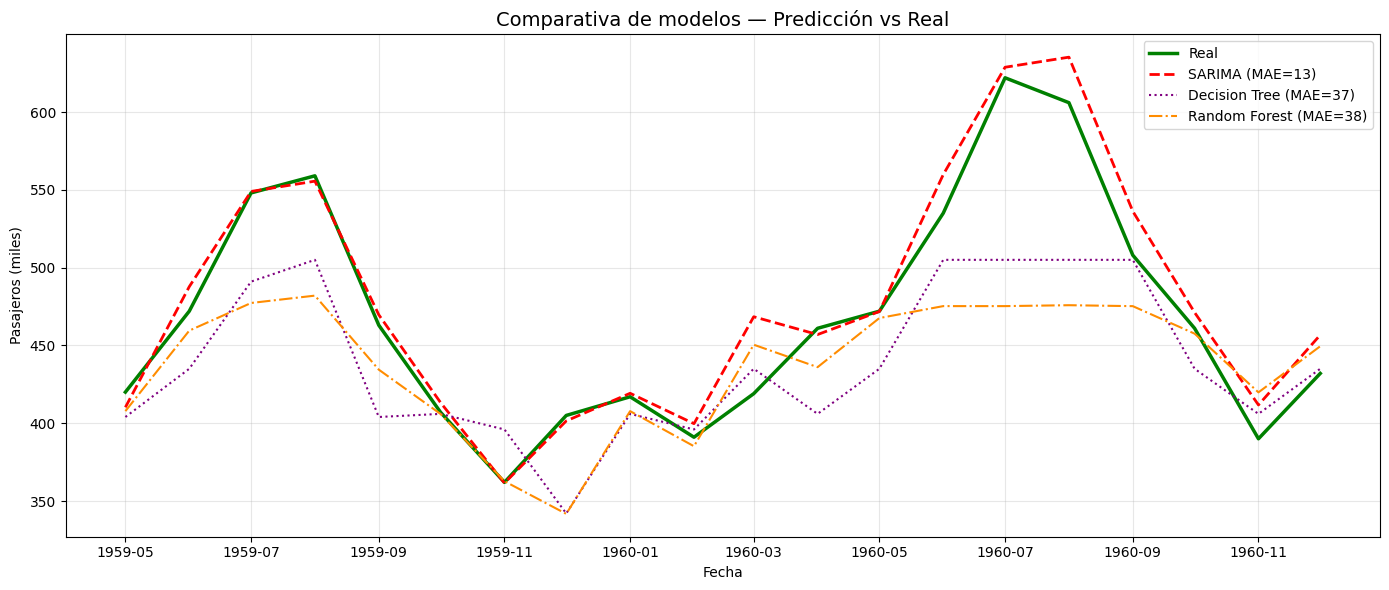


Conclusión:
SARIMA es muy superior porque está diseñado específicamente para series temporales.
Captura tendencia, estacionalidad y autocorrelación de forma explícita.
Los modelos de ML con lag features no modelan esa estructura de forma nativa.


In [9]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Creamos lag features: usamos los últimos 12 valores como predictores
n_lags = 12
df_ml = pd.DataFrame({'y': df['log_value']})
for i in range(1, n_lags + 1):
    df_ml[f'lag_{i}'] = df_ml['y'].shift(i)
df_ml = df_ml.dropna()

# Split cronológico: mismas fechas que antes
split_idx = len(df_ml) - 20
X_train = df_ml.iloc[:split_idx].drop(columns='y')
y_train = df_ml.iloc[:split_idx]['y']
X_test  = df_ml.iloc[split_idx:].drop(columns='y')
y_test  = df_ml.iloc[split_idx:]['y']

# Modelo 1: Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
pred_dt_log = dt.predict(X_test)
pred_dt_real = np.exp(pred_dt_log)
y_test_real  = np.exp(y_test.values)

mae_dt  = mean_absolute_error(y_test_real, pred_dt_real)
rmse_dt = np.sqrt(mean_squared_error(y_test_real, pred_dt_real))

# Modelo 2: Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
pred_rf_log  = rf.predict(X_test)
pred_rf_real = np.exp(pred_rf_log)

mae_rf  = mean_absolute_error(y_test_real, pred_rf_real)
rmse_rf = np.sqrt(mean_squared_error(y_test_real, pred_rf_real))

# Comparativa final
print('=== Comparativa de modelos (en pasajeros reales) ===')
print(f'  SARIMA:         MAE={mae:.1f}   RMSE={rmse:.1f}')
print(f'  Decision Tree:  MAE={mae_dt:.1f}   RMSE={rmse_dt:.1f}')
print(f'  Random Forest:  MAE={mae_rf:.1f}   RMSE={rmse_rf:.1f}')

# Gráfica comparativa
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test.index, y_test_real,
        color='green', linewidth=2.5, label='Real')
ax.plot(test.index, pred_real,
        color='red', linewidth=2, linestyle='--',
        label=f'SARIMA (MAE={mae:.0f})')
ax.plot(test.index[:len(pred_dt_real)], pred_dt_real,
        color='purple', linewidth=1.5, linestyle=':',
        label=f'Decision Tree (MAE={mae_dt:.0f})')
ax.plot(test.index[:len(pred_rf_real)], pred_rf_real,
        color='darkorange', linewidth=1.5, linestyle='-.',
        label=f'Random Forest (MAE={mae_rf:.0f})')
ax.set_title('Comparativa de modelos — Predicción vs Real', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('Pasajeros (miles)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nConclusión:')
print('SARIMA es muy superior porque está diseñado específicamente para series temporales.')
print('Captura tendencia, estacionalidad y autocorrelación de forma explícita.')
print('Los modelos de ML con lag features no modelan esa estructura de forma nativa.')